In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from scipy.stats import zscore
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [22]:
df=pd.read_csv(r"C:\Users\ms_ju\Downloads\Diabetes Prediction\diabetes_prediction_dataset.csv")
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [4]:
zero_val=(df[['gender', 'age', 'bmi', 'HbA1c_level', 'blood_glucose_level']]==0).sum()
print(zero_val)

gender                 0
age                    0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
dtype: int64


C:\Users\ms_ju\AppData\Local\Temp\ipykernel_29516\935005675.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax= sns.barplot(x=percentages.index, y=percentages.values, palette='YlGnBu')
C:\Users\ms_ju\AppData\Local\Temp\ipykernel_29516\935005675.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Non-diabetic', 'Diabetic'])


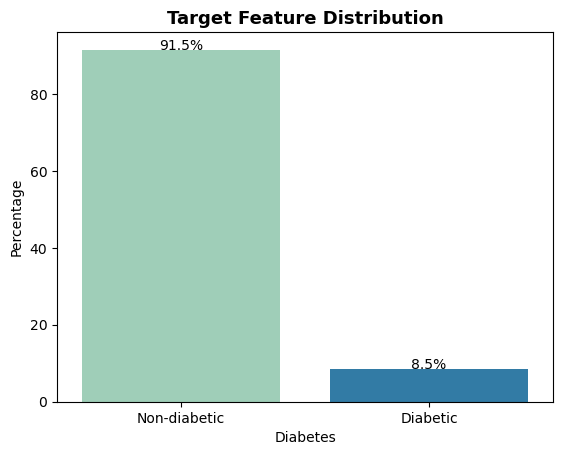

In [5]:
plt.figure()
percentages = df['diabetes'].value_counts(normalize=True) * 100
ax= sns.barplot(x=percentages.index, y=percentages.values, palette='YlGnBu')
ax.set_xticklabels(['Non-diabetic', 'Diabetic'])
for bar, pct in zip(ax.patches, percentages.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{pct:.1f}%', ha='center')
plt.title('Target Feature Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Diabetes')
plt.ylabel('Percentage')
plt.show()

Text(0.5, 1.0, 'blood_glucose_level Distribution')

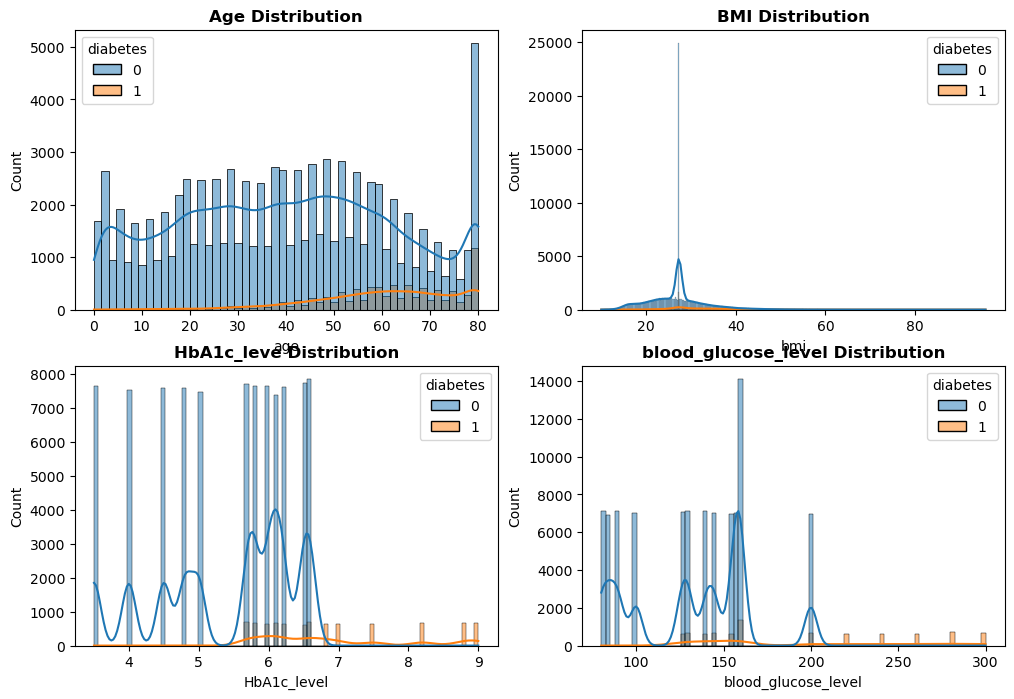

In [6]:
fig, axes= plt.subplots(2,2, figsize=(12,8))
sns.histplot(data=df, x='age', hue='diabetes', kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Age Distribution', fontweight='bold')
sns.histplot(data=df, x='bmi', hue='diabetes', kde=True, ax=axes[0, 1])
axes[0,1].set_title('BMI Distribution', fontweight='bold')
sns.histplot(data=df, x='HbA1c_level', hue='diabetes', kde=True, ax=axes[1, 0])
axes[1,0].set_title('HbA1c_leve Distribution', fontweight='bold')
sns.histplot(data=df, x='blood_glucose_level', hue='diabetes', kde=True, ax=axes[1, 1])
axes[1,1].set_title('blood_glucose_level Distribution', fontweight='bold')

In [24]:
scaler=MinMaxScaler()
norm_col=['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
df[norm_col]=scaler.fit_transform(df[norm_col])
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,1.000000,0,1,never,0.177171,0.563636,0.272727,0
1,Female,0.674675,0,0,No Info,0.202031,0.563636,0.000000,0
2,Male,0.349349,0,0,never,0.202031,0.400000,0.354545,0
3,Female,0.449449,0,0,current,0.156863,0.272727,0.340909,0
4,Male,0.949950,1,1,current,0.118231,0.236364,0.340909,0


In [25]:
le=LabelEncoder()
df['gender']=le.fit_transform(df['gender'])
df['smoking_history']=le.fit_transform(df['smoking_history'])
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,1.000000,0,1,4,0.177171,0.563636,0.272727,0
1,0,0.674675,0,0,0,0.202031,0.563636,0.000000,0
2,1,0.349349,0,0,4,0.202031,0.400000,0.354545,0
3,0,0.449449,0,0,1,0.156863,0.272727,0.340909,0
4,1,0.949950,1,1,1,0.118231,0.236364,0.340909,0


In [14]:
x=df.drop('diabetes', axis=1)
y=df['diabetes']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [15]:
#xgb= XGBClassifier(eval_metric='logloss', random_state=42)

scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

#model = XGBClassifier(
    #scale_pos_weight=scale_pos_weight,
    #random_state=42
#)
xgb= XGBClassifier(
    max_depth=4,          # shallower trees
    n_estimators=300,     # fewer boosting rounds
    learning_rate=0.08,   # smaller steps
    subsample=0.8,        # use fraction of rows
    colsample_bytree=0.8, # use fraction of features
    scale_pos_weight=scale_pos_weight,
    reg_lambda=1,         # L2 regularization
    reg_alpha=0.5,        # L1 regularization
    random_state=42,
    eval_metric="logloss",
    #early_stopping_rounds=20
)
xgb.fit(x_train, y_train, 
        eval_set=[(x_test, y_test)],
        verbose=False)
y_train_probs = xgb.predict_proba(x_train)[:, 1]
y_probs = xgb.predict_proba(x_test)[:, 1]
threshold = 0.85
xgb_preds = (y_probs > threshold).astype(int)
train_preds = (y_train_probs > threshold).astype(int)
#xgb_preds=xgb.predict(x_test)
xgb_acc=accuracy_score(y_test, xgb_preds)
train_acc=accuracy_score(y_train, train_preds)
print(f'Train Accuracy score is:{train_acc*100:0.2F}%')
print(f'Testing Accuracy score is:{xgb_acc*100:0.2F}%')

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, xgb_preds))

from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb, x, y, cv=5)
print(f'Cross value score {scores.mean()*100:0.2F}%')

cm=confusion_matrix(y_test, xgb_preds)
print("Confusion Matrix:\n", cm)

Train Accuracy score is:97.15%
Testing Accuracy score is:97.06%
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     18300
           1       0.91      0.73      0.81      1700

    accuracy                           0.97     20000
   macro avg       0.94      0.86      0.90     20000
weighted avg       0.97      0.97      0.97     20000

Cross value score 90.88%
Confusion Matrix:
 [[18172   128]
 [  460  1240]]


In [16]:
import joblib

joblib.dump(xgb, 'diabetes_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print('Model and scaler saved successfully')

Model and scaler saved successfully
